# Events as outcomes

- (A) We are looking for number of patients requiring ICU, vent, vasopressor, CRRT, bolus before and after their sepsis3 time.
- (B) Also, tracking post-sepsis ICU LOS, vent free days, vasopressor free days, short term mortality in next 28 days.

# (A)

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_sepsis_wavmatched = pd.read_csv('../pitts_emr_data/df_step0_WaveMatchedSepsisPats_table_HS.csv')
df_unit = pd.read_csv('../pitts_emr_data/pitts_hospital_unit.csv')
df_crrt = pd.read_csv('../pitts_emr_data/pitts_CRRT.csv')
df_imv = pd.read_csv('../pitts_emr_data/vitals_IMVvent.csv')

In [3]:
df_unit['studyID'] = df_unit.Study_ID.values
df_unit['fin'] = df_unit.FIN_study_id.values
df_crrt['studyID'] = df_crrt.study_id.values
df_crrt['fin'] = df_crrt.FIN_study_id.values
df_imv['studyID'] = df_imv.study_id.values
df_imv['fin'] = df_imv.FIN_study_id.values

# ICU

In [ ]:
df = df_sepsis_wavmatched.merge(df_unit, how='left', on=['studyID','fin'])
# df = df_sepsis[~df_sepsis['unit'].isnull()]
df['T_icu_start'] = df.BEG_DATE.copy()
df['T_icu_end'] = df.END_DATE.copy()
df['icu_unit'] = df.unit.copy()
df = df[['fin', 'studyID', 'year_sepsis', 'T_icu_start', 'T_icu_end', 'icu_unit', 't_sepsis', 'T_vp_postS3',
       'VP_name', 'T_bolus_preS3', 'T_bolus_postS3', 'facility']]
df = df.drop_duplicates().reset_index(drop=True)
df

In [5]:
df.columns

Index(['fin', 'studyID', 'year_sepsis', 'T_icu_start', 'T_icu_end', 'icu_unit',
       't_sepsis', 'T_vp_postS3', 'VP_name', 'T_bolus_preS3', 'T_bolus_postS3',
       'facility'],
      dtype='object')

In [6]:
'''
For a same encounter, merge row entries if df.loc[0,'T_icu_end'] == df.loc[1,'T_icu_start'] then 
keep df.loc[0,'T_icu_start'] and df.loc[1,'T_icu_end']
'''

"\nFor a same encounter, merge row entries if df.loc[0,'T_icu_end'] == df.loc[1,'T_icu_start'] then \nkeep df.loc[0,'T_icu_start'] and df.loc[1,'T_icu_end']\n"

In [ ]:
df['T_icu_start'] = pd.to_datetime(df['T_icu_start'])
df['T_icu_end'] = pd.to_datetime(df['T_icu_end'])
df = df.sort_values(by=['fin','T_icu_start','T_icu_end'])
df.drop(['icu_unit'], axis=1, inplace=True)
df

In [8]:
df_fin = df.fin.unique()
df1 = pd.DataFrame()
for k, fin_k in tqdm(enumerate(df_fin)):
    df_k = df[df.fin == fin_k]
    df_k.reset_index(inplace=True)
    idx = []
    for i in range(df_k.shape[0]-1):
        if df_k.loc[i,'T_icu_end'] == df_k.loc[i+1,'T_icu_start']:
            df_k.loc[i+1,'T_icu_start'] = df_k.loc[i,'T_icu_start']
            idx.append(i) # For dropping rows
            
    df_k.drop(idx, inplace=True)
    df1 = pd.concat([df1, df_k], ignore_index=True)
    
    #if k==5: break

4041it [00:04, 961.96it/s]


In [ ]:
df1

In [10]:
df1.columns

Index(['index', 'fin', 'studyID', 'year_sepsis', 'T_icu_start', 'T_icu_end',
       't_sepsis', 'T_vp_postS3', 'VP_name', 'T_bolus_preS3', 'T_bolus_postS3',
       'facility'],
      dtype='object')

In [11]:
df1.VP_name.unique()

array(['norepinephrine', nan, 'phenylephrine', 'EPINEPHrine',
       'vasopressin', 'DOPamine'], dtype=object)

In [12]:
df1.facility.unique()

array(['UPMCPUH', nan], dtype=object)

In [13]:
df1.fin.nunique(), df_sepsis_wavmatched.fin.nunique()

(4041, 4041)

In [ ]:
df1[df1['T_icu_start'].isnull()].fin.unique()    ## For 31 patient encounters, we don't have ICU times (so, were they not admitted to ICU.)

In [ ]:
df1['T_icu_postS3'] = df1['T_icu_start'].copy()
df_icu_gp1 = df1[(~df1['T_icu_postS3'].isnull()) & (df1['T_icu_postS3'] > df1['t_sepsis'])]
df_icu_gp2 = df1[df1['T_icu_postS3'].isnull()]
df1_1 = pd.concat([df_icu_gp1, df_icu_gp2])
df1_1['T_icu_preS3'] = pd.NaT

df_icu_gp3 = df1[(~df1['T_icu_postS3'].isnull()) & (df1['T_icu_postS3'] <= df1['t_sepsis'])]
df_icu_gp3['T_icu_preS3'] = df_icu_gp3['T_icu_postS3'].copy()
df_icu_gp3['T_icu_postS3'] = pd.NaT

df1_2 = pd.concat([df1_1, df_icu_gp3])
df1_2.reset_index(drop=True, inplace=True)
df1_2

In [16]:
df1 = df1_2.copy()

In [ ]:
df1

# CRRT

In [ ]:
df_crrt

In [19]:
df_crrt.UNIT.isnull().sum()

0

In [20]:
df_crrt['T_crrt_postS3'] = df_crrt.EVENT_DATE.values
df_crrt['crrt_volume'] = df_crrt['VOLUME'].values
df_crrt['crrt_vol_unit'] = df_crrt['UNIT'].values

In [ ]:
df_crrt_wav = df1.merge(df_crrt[['studyID','fin','T_crrt_postS3','crrt_volume','crrt_vol_unit']].drop_duplicates().reset_index(drop=True), how='left', on=['studyID','fin'])
# df_crrt_wav[~df_crrt_wav.year_sepsis.isnull()]
df_crrt_wav

In [22]:
df_crrt_wav['t_sepsis'] = pd.to_datetime(df_crrt_wav.t_sepsis)
df_crrt_wav['T_crrt_postS3'] = pd.to_datetime(df_crrt_wav.T_crrt_postS3)

In [ ]:
df_crrt_wav_gp1 = df_crrt_wav[(~df_crrt_wav['T_crrt_postS3'].isnull()) & (df_crrt_wav['T_crrt_postS3'] > df_crrt_wav['t_sepsis'])]
df_crrt_wav_gp2 = df_crrt_wav[df_crrt_wav['T_crrt_postS3'].isnull()]
df2 = pd.concat([df_crrt_wav_gp1, df_crrt_wav_gp2])
df2['T_crrt_preS3'] = pd.NaT

df_crrt_wav_gp3 = df_crrt_wav[(~df_crrt_wav['T_crrt_postS3'].isnull()) & (df_crrt_wav['T_crrt_postS3'] <= df_crrt_wav['t_sepsis'])]
df_crrt_wav_gp3['T_crrt_preS3'] = df_crrt_wav_gp3['T_crrt_postS3'].copy()
df_crrt_wav_gp3['T_crrt_postS3'] = pd.NaT

df3 = pd.concat([df2, df_crrt_wav_gp3])
df3.reset_index(drop=True, inplace=True)
df3

# IMV

In [ ]:
df_imv

In [25]:
df_imv['T_imv_postS3'] = pd.to_datetime(df_imv.chartdate)

In [ ]:
df_imv_wav = df3.merge(df_imv[['studyID','fin','T_imv_postS3']].drop_duplicates().reset_index(drop=True), how='left', on=['studyID','fin'])
df_imv_wav

In [ ]:
df_imv_wav['t_sepsis'] = pd.to_datetime(df_imv_wav.t_sepsis)
df_imv_wav['T_imv_postS3'] = pd.to_datetime(df_imv_wav.T_imv_postS3)

df_imv_wav_gp1 = df_imv_wav[(~df_imv_wav['T_imv_postS3'].isnull()) & (df_imv_wav['T_imv_postS3'] > df_imv_wav['t_sepsis'])]
df_imv_wav_gp2 = df_imv_wav[df_imv_wav['T_imv_postS3'].isnull()]
df4 = pd.concat([df_imv_wav_gp1, df_imv_wav_gp2])
df4['T_imv_preS3'] = pd.NaT

df_imv_wav_gp3 = df_imv_wav[(~df_imv_wav['T_imv_postS3'].isnull()) & (df_imv_wav['T_imv_postS3'] <= df_imv_wav['t_sepsis'])]
df_imv_wav_gp3['T_imv_preS3'] = df_imv_wav_gp3['T_imv_postS3'].copy()
df_imv_wav_gp3['T_imv_postS3'] = pd.NaT

df5 = pd.concat([df4, df_imv_wav_gp3])
df5.reset_index(drop=True, inplace=True)
df5


In [28]:
ufin = df5.fin.unique()
len(ufin)

4041

In [29]:
'''
Identify:

How many went to ICU after S3.
How many went to ICU before S3.
How many got VP after S3. 
How many got bolus after S3.
How many got bolus before S3.
How many got CRRT after S3. 
How many got CRRT before S3.
How many got IMV after S3.
How many got IMV before S3.
How many died after S3
'''

'\nIdentify:\n\nHow many went to ICU after S3.\nHow many went to ICU before S3.\nHow many got VP after S3. \nHow many got bolus after S3.\nHow many got bolus before S3.\nHow many got CRRT after S3. \nHow many got CRRT before S3.\nHow many got IMV after S3.\nHow many got IMV before S3.\n'

In [30]:
df5['T_icu_preS3'] = pd.to_datetime(df5.T_icu_preS3)
df5['T_icu_postS3'] = pd.to_datetime(df5.T_icu_postS3)
df5['t_sepsis'] = pd.to_datetime(df5.t_sepsis)
df5['T_vp_postS3'] = pd.to_datetime(df5.T_vp_postS3)
df5['T_bolus_preS3'] = pd.to_datetime(df5.T_bolus_preS3)
df5['T_bolus_postS3'] = pd.to_datetime(df5.T_bolus_postS3)
df5['T_imv_postS3'] = pd.to_datetime(df5.T_imv_postS3)
df5['T_crrt_postS3'] = pd.to_datetime(df5.T_crrt_postS3)
df5['T_crrt_preS3'] = pd.to_datetime(df5.T_crrt_preS3)
df5['T_imv_postS3'] = pd.to_datetime(df5.T_imv_postS3)
df5['T_imv_preS3'] = pd.to_datetime(df5.T_imv_preS3)

In [31]:
C_vp_postS3 = 0
C_bolus_preS3 = 0
C_bolus_postS3 = 0
C_crrt_preS3 = 0
C_crrt_postS3 = 0
C_imv_preS3 = 0
C_imv_postS3 = 0
C_icu_preS3 = 0
C_icu_postS3 = 0
for i, uf in tqdm(enumerate(ufin)):
    z = df5[df5.fin==uf]
    #z.T_icu_start < 
    if (~z.T_vp_postS3.isnull()).sum()>0: C_vp_postS3 = C_vp_postS3 + 1    
    if (~z.T_icu_preS3.isnull()).sum()>0: C_icu_preS3 = C_icu_preS3 + 1
    if (~z.T_icu_postS3.isnull()).sum()>0: C_icu_postS3 = C_icu_postS3 + 1    
    if (~z.T_bolus_preS3.isnull()).sum()>0: C_bolus_preS3 = C_bolus_preS3 + 1
    if (~z.T_bolus_postS3.isnull()).sum()>0: C_bolus_postS3 = C_bolus_postS3 + 1
    if (~z.T_crrt_preS3.isnull()).sum()>0: C_crrt_preS3 = C_crrt_preS3 + 1
    if (~z.T_crrt_postS3.isnull()).sum()>0: C_crrt_postS3 = C_crrt_postS3 + 1
    if (~z.T_imv_preS3.isnull()).sum()>0: C_imv_preS3 = C_imv_preS3 + 1
    if (~z.T_imv_postS3.isnull()).sum()>0: C_imv_postS3 = C_imv_postS3 + 1
    
    

4041it [00:17, 226.74it/s]


In [32]:
counts = {'vp_postS3':100*C_vp_postS3/len(ufin),'icu_preS3':100*C_icu_preS3/len(ufin), 'icu_postS3':100*C_icu_postS3/len(ufin),
          'bolus_preS3':100*C_bolus_preS3/len(ufin),'bolus_postS3':100*C_bolus_postS3/len(ufin),'crrt_preS3':100*C_crrt_preS3/len(ufin),'crrt_postS3':100*C_crrt_postS3/len(ufin), 'imv_preS3':100*C_imv_preS3/len(ufin),'imv_postS3':100*C_imv_postS3/len(ufin)}
counts

{'vp_postS3': 49.49269982677555,
 'icu_preS3': 37.787676317743134,
 'icu_postS3': 68.0029695619896,
 'bolus_preS3': 16.87701064093046,
 'bolus_postS3': 77.85201682751794,
 'crrt_preS3': 0.5444196980945311,
 'crrt_postS3': 8.958178668646374,
 'imv_preS3': 20.613709477852016,
 'imv_postS3': 47.58723088344469}

<AxesSubplot:ylabel='Count (%)'>

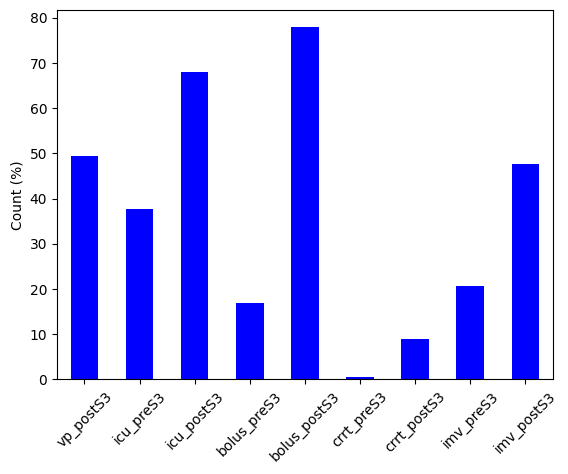

In [33]:
pd.Series(counts).plot.bar(rot=45, color='blue', ylabel='Count (%)')

# (B) tracking post-sepsis ICU LOS, vent free days, vasopressor free days, short term mortality in next 28 days.